In [ ]:
###
    # This code assessed the Gaussianity assumption for the emergent constraint framework
    # Using Q–Q plots and Shapiro–Wilk test
    # Output: Figure S18.
###

In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import math
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

160
240
320


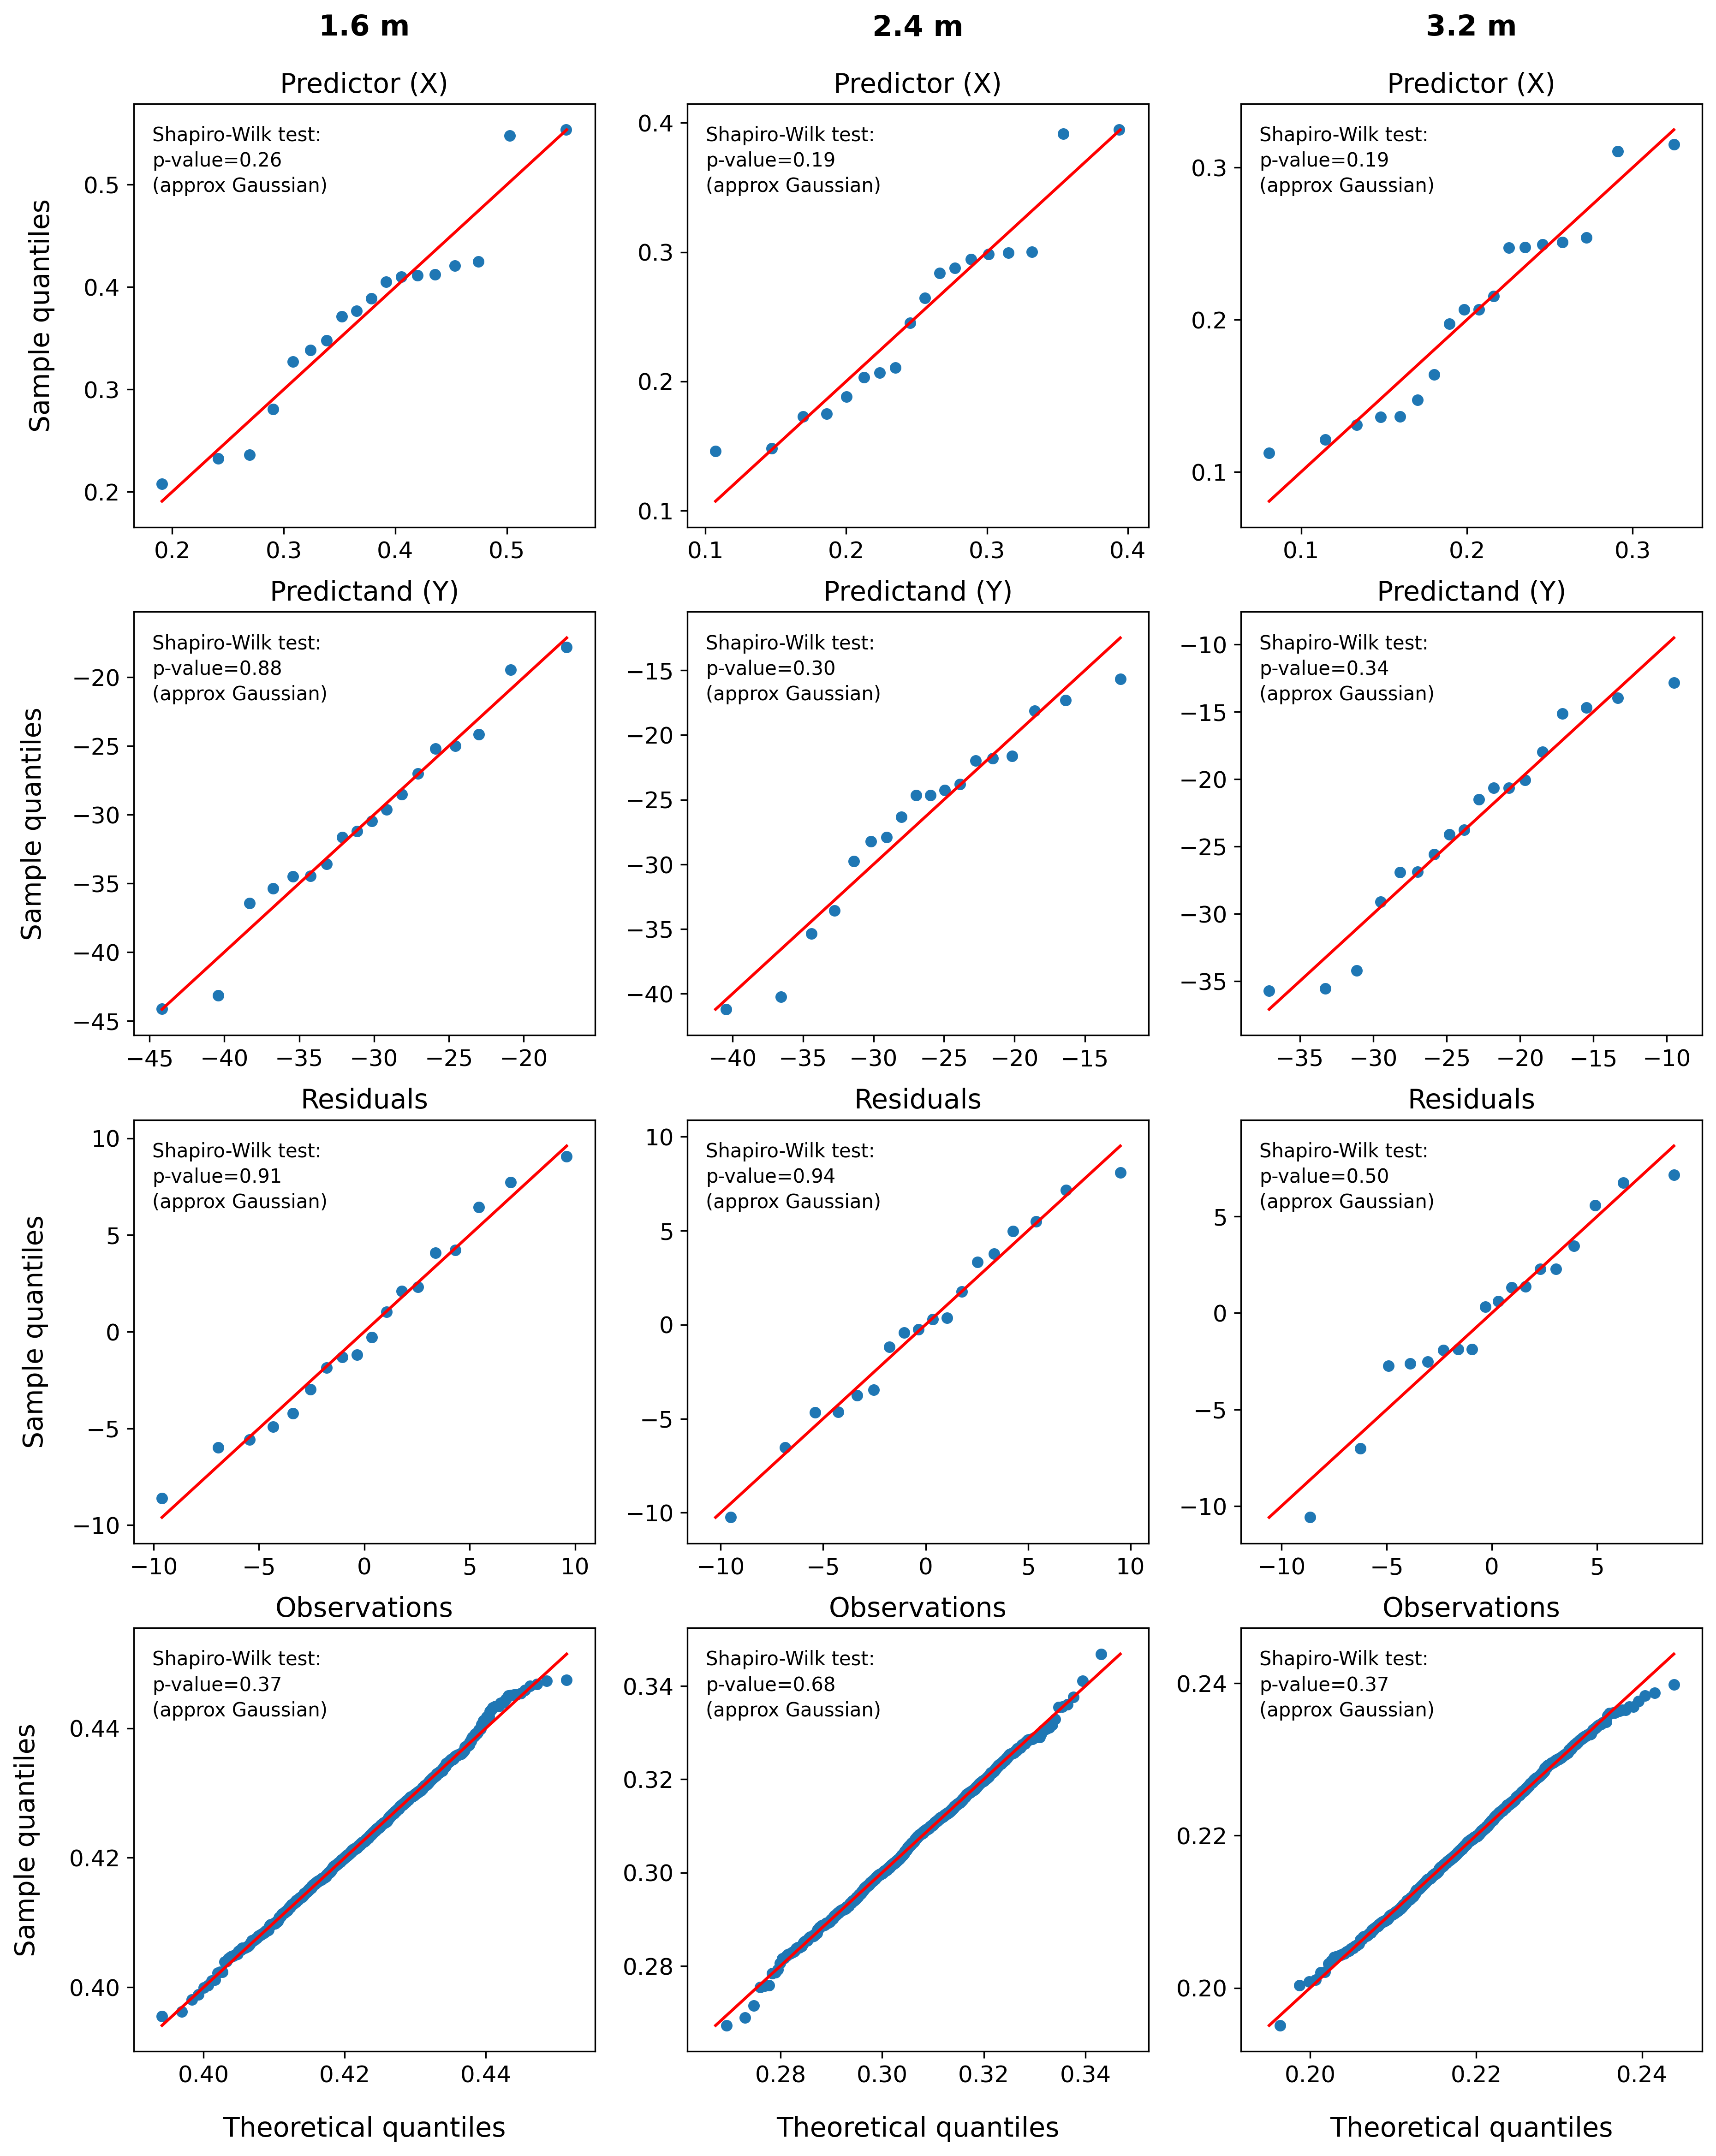

In [ ]:
# Calculate the grid areas
def area(lat, grid_resolution):    
    rad = np.pi / 180.0
    lat_rad = lat * rad

    # Calculate the latitude and longitude resolution
    re = 6371220.0  # Earth radius (in meters)
    dlon = grid_resolution * rad  # Longitude resolution (in radians)
    dlat = grid_resolution * rad  # Latitude resolution (in radians)

    # Calculate the area of each grid cell
    sin_lat1 = np.sin(lat_rad + dlat / 2)
    sin_lat2 = np.sin(lat_rad - dlat / 2)
    grid_areas = (re ** 2) * dlon * (sin_lat1 - sin_lat2)
    return grid_areas

# Grids the station data and calculates grid areas to facilitate subsequent area-weighted averaging
def grid_data(data, grid_resolution):
    grid_Mean = pd.DataFrame(columns=data.columns[2:])
    grid_Mean['area']=''
    latmin, latmax = data['Lat'].min(), data['Lat'].max()
    m = math.ceil((latmax - latmin) / grid_resolution)
    line = 0
    for j in range(m):
        data1 = data[(data['Lat'] >= latmin + grid_resolution * j) & (data['Lat'] < latmin + grid_resolution * (j + 1))]
        if data1.empty:
            continue
        minlon, maxlon = data1['Lon'].min(), data1['Lon'].max()
        n = math.ceil((maxlon - minlon) / grid_resolution)
        for i in range(n):
            data2 = data1[(data1['Lon'] >= minlon + grid_resolution * i) & (data1['Lon'] < minlon + grid_resolution * (i + 1))]
            grid_Mean.loc[line] = data2.mean()
            grid_Mean['area'].loc[line] = area((latmin + grid_resolution * (j+0.5)),grid_resolution)
            line += 1
    return grid_Mean.dropna()

# Function to read data from a file
def read_data_file(file_path):
    with open(file_path) as file:
        return [float(line.strip()) for line in file.readlines()]

# ====== Unified Q-Q function ======
def qq_plot_1to1_ax(data, ax, title):
    data = np.asarray(data, dtype=np.float64)
    data = data[np.isfinite(data)]
    
    # Sort
    sample_q = np.sort(data)
    
    # Theoretical quantiles
    n = len(sample_q)
    probs = (np.arange(1, n+1) - 0.5) / n
    z_theory = stats.norm.ppf(probs)
    
    # Transform to data space
    mu = np.mean(data)
    sigma = np.std(data, ddof=1)
    theory_q = mu + sigma * z_theory
    
    # Scatter plot
    ax.scatter(theory_q, sample_q, s=25)
    
    # 1:1 line
    min_val = min(theory_q.min(), sample_q.min())
    max_val = max(theory_q.max(), sample_q.max())
    ax.plot([min_val, max_val], [min_val, max_val], linestyle='-', color='red')
    
    # ====== Set x and y axes to the same range ======
    # Add some margin
    margin = (max_val - min_val) * 0.07
    axis_range = (min_val - margin, max_val + margin)
    
    # Set x and y axes to the same range
    ax.set_xlim(axis_range)
    ax.set_ylim(axis_range)

    ax.set_title(title,fontsize = 14)
    ax.tick_params(axis='both', labelsize=12)  # labelsize controls tick label font size

    stat, p = stats.shapiro(data)
    ax.text(0.04, 0.925,f"Shapiro-Wilk test:", ha='left', va='center', transform=ax.transAxes, fontsize=10)
    ax.text(0.04, 0.865,f"p-value={p:.2f}", ha='left', va='center', transform=ax.transAxes, fontsize=10)
    if p > 0.05:
        ax.text(0.04, 0.805,f"(approx Gaussian)", ha='left', va='center', transform=ax.transAxes, fontsize=10)
    else:
        ax.text(0.04, 0.805,f"(NOT Gaussian)", ha='left', va='center', transform=ax.transAxes, fontsize=10)

# ====== One row and three columns ======
fig, axes = plt.subplots(4, 3, figsize=(12.5, 16), dpi=300)
col_titles = ['1.6 m', '2.4 m', '3.2 m']

model_order = ["CESM2","CESM2-FV2","CESM2-WACCM","CNRM-CM6-1-HR","CNRM-CM6-1","CNRM-ESM2-1",
               "E3SM-1-1","FGOALS-f3-L","FGOALS-g3","GFDL-CM4","GFDL-ESM4","MIROC6",
               "MIROC-ES2L","MPI-ESM1-2-HR","MPI-ESM1-2-LR","NorESM2-LM","NorESM2-MM","TaiESM1"]

# Define excluded models as a set for faster lookup
excluded_models = {
    "KACE-1-0", "CanESM5", "CanESM5-CanOE", "IPSL-CM6A-LR"
    ,"CAS-ESM2-0","CMCC-CM2-SR5", "CMCC-ESM2"
}
for d,depth in enumerate(['160','240','320']):
    print(depth)
    pf_stations_filtered=pd.read_csv(f"../Data/Ts_seasonal_sensitivity/Ts_Ts02_obs_NH45_18model_{depth}cm_interpolated.csv")
    
    # Calculate the multi-year average soil temperature sensitivity for each station
    pf_stations_years_ave = pf_stations_filtered.groupby('station').mean().reset_index().sort_values(by='station')
    pf_stations_years_ave = pf_stations_years_ave.iloc[:,3:6]
    
    ## -----------------------------------------------------------------------------------------------------------------------------
    #      Perform gridding processing on soil temperature sensitivity for all stations, 
    #      then calculate spatial average (including one value for observations and each model respectively)
    ## -----------------------------------------------------------------------------------------------------------------------------
    grid_resolution = 2.5
    n_bootstrap = 1000  # Number of sampling iterations
    station_means = []

    # Bootstrap sampling method
    for _ in range(n_bootstrap):
        
        # Sample len(pf_stations_years_ave) stations with replacement
        sampled_df = pf_stations_years_ave.sample(n=len(pf_stations_years_ave), replace=True)
        
        # Calculate the station average for this sampling iteration (each sampling undergoes gridding processing first, then calculates area-weighted average after gridding)
        grid_station = grid_data(sampled_df, grid_resolution)
        weighted_avg_models = {
            col: (grid_station[col] * grid_station["area"]).sum() / grid_station["area"].sum()
            for col in grid_station.columns[:]
        }
        station_means.append(weighted_avg_models)
    station_means = pd.DataFrame(station_means)
    station_means.to_csv("Ts"+depth+"cm_obs.csv")
    
    # Read permafrost sensitivity data from CSV file
    file_path = "../Data/Permafrost_sensitivity/" + depth + "cm_permafrost_sensitivity_under_climate_change_ssp585.csv"
    pfarea_dt = pd.read_csv(file_path).set_index('model').loc[model_order]
    pfarea_dt3, pfarea_dt2, pfarea_dt15 = pfarea_dt['3'], pfarea_dt['2'], pfarea_dt['1.5']
    
    # Read soil temperature sensitivity data (sorted by model order)
    Ts_path = f"../Data/Ts_seasonal_sensitivity/Ts"+depth+"cm_Ts02_all_station_avg_obs_18model.txt"
    Ts_dt = read_data_file(Ts_path)
    
    # Filter out excluded models
    midx = [model not in excluded_models for model in model_order]
    X = np.array(Ts_dt[:-2])
    Y = pfarea_dt3[midx].values
    
    # ====== Calculate residuals ======
    slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)
    Y_pred = slope * X + intercept
    residuals = Y - Y_pred
    
    if d==0:
        axes[1,d].set_ylabel("Sample quantiles",labelpad = 13, fontsize=14)
        axes[2,d].set_ylabel("Sample quantiles",labelpad = 12, fontsize=14)
        axes[0,d].set_ylabel("Sample quantiles",labelpad = 15, fontsize=14)
        axes[3,d].set_ylabel("Sample quantiles",labelpad = 15, fontsize=14)
    
    # ====== Set fixed tick spacing ======
    # Set x and y axes to use the same tick spacing
    axes[0,d].xaxis.set_major_locator(ticker.MultipleLocator(0.1))
    axes[0,d].yaxis.set_major_locator(ticker.MultipleLocator(0.1))
    axes[1,d].xaxis.set_major_locator(ticker.MultipleLocator(5))
    axes[1,d].yaxis.set_major_locator(ticker.MultipleLocator(5))
    axes[2,d].xaxis.set_major_locator(ticker.MultipleLocator(5))
    axes[2,d].yaxis.set_major_locator(ticker.MultipleLocator(5))
    axes[3,d].xaxis.set_major_locator(ticker.MultipleLocator(0.02))
    axes[3,d].yaxis.set_major_locator(ticker.MultipleLocator(0.02))

    qq_plot_1to1_ax(X, axes[0,d], "Predictor (X)")
    qq_plot_1to1_ax(Y, axes[1,d], "Predictand (Y)")        
    qq_plot_1to1_ax(residuals, axes[2,d], "Residuals")        
    qq_plot_1to1_ax(station_means['obs_Ts_Ts02'], axes[3,d], "Observations")
    axes[3,d].set_xlabel("Theoretical quantiles",labelpad = 15, fontsize=14)
    
    # Set column titles
    axes[0, d].text(0.5, 1.18,col_titles[d], ha='center', va='center', fontweight='bold', transform=axes[0, d].transAxes, fontsize=15)

plt.tight_layout()
plt.subplots_adjust(top=0.93,     # Distance from top of subplots
                    wspace=0.2,  # Horizontal spacing between subplots
                    hspace=0.2)   # Vertical spacing between subplots
plt.show()

In [ ]:
fig.savefig("../Figures/FigureS18.png", bbox_inches='tight',dpi=300)